
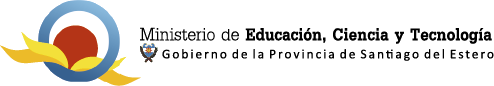

# Examen Final

## Materia: Aprendizaje Automático

## Contenidos a evualar:

* Modulo I
* Modulo II
* Modulo III
* Modulo IV

## Docente: Juana María López
## Fecha: 24 de Setiembre 2026


# Cargamos dataset

### Descripcion del dataset:
### 🩺 Breast Cancer Wisconsin Dataset

El Breast Cancer Wisconsin (Diagnostic) Dataset es un conjunto de datos clásico en Machine Learning, ampliamente utilizado para tareas de clasificación binaria y análisis exploratorio.

Contiene mediciones obtenidas a partir de imágenes digitalizadas de aspiraciones con aguja fina (FNA) de masas mamarias.
Cada muestra describe las propiedades morfológicas de los núcleos celulares del tumor, con el objetivo de predecir si el tumor es maligno o benigno.

🎯 Objetivo (Target)

El objetivo es predecir la variable target, que indica la naturaleza del tumor:

Valor	Diagnóstico
0	Maligno
1	Benigno

| Categoría         | Ejemplo de variables                                                           |
| ----------------- | ------------------------------------------------------------------------------ |
| Radio             | `mean radius`, `radius error`, `worst radius`                                  |
| Textura           | `mean texture`, `texture error`, `worst texture`                               |
| Perímetro         | `mean perimeter`, `perimeter error`, `worst perimeter`                         |
| Área              | `mean area`, `area error`, `worst area`                                        |
| Suavidad          | `mean smoothness`, `smoothness error`, `worst smoothness`                      |
| Compacidad        | `mean compactness`, `compactness error`, `worst compactness`                   |
| Concavidad        | `mean concavity`, `concavity error`, `worst concavity`                         |
| Puntos cóncavos   | `mean concave points`, `concave points error`, `worst concave points`          |
| Simetría          | `mean symmetry`, `symmetry error`, `worst symmetry`                            |
| Dimensión fractal | `mean fractal dimension`, `fractal dimension error`, `worst fractal dimension` |


In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Cargar dataset desde sklearn
data = load_breast_cancer()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Agregar columna target
df["target"] = data.target


In [2]:
# Mostrar forma y primeras filas
print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Consignas :
Se trabajará con el Breast Cancer Wisconsin Dataset (scikit-learn). Este dataset contiene información sobre tumores mamarios, con 30 características celulares y un target binario que indica si el tumor es maligno (0) o benigno (1).

* 1) Deberan entrenar un modelo para predecir la columna target (0 = maligno, 1 = benigno).

¿Qué variables son las más importantes para predecir la columna target?

* 2) Realizar clustering de pacientes, procurando responder las siguientes preguntas:

¿Cuántos clusters de pacientes identificas con K-Means?

¿Qué características celulares diferencian a los clusters?

¿Podrías usar el resultado del clustering para priorizar pacientes o diseñar estrategias de seguimiento?

### 1) Entrenamiento de modelo para predecir la columna target y análisis de importancia de características.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Separar características (X) y target (y)
X = df.drop('target', axis=1)
y = df['target']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (398, 30)
Dimensiones de X_test: (171, 30)
Dimensiones de y_train: (398,)
Dimensiones de y_test: (171,)


/tmp/ipykernel_840/2347045230.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')


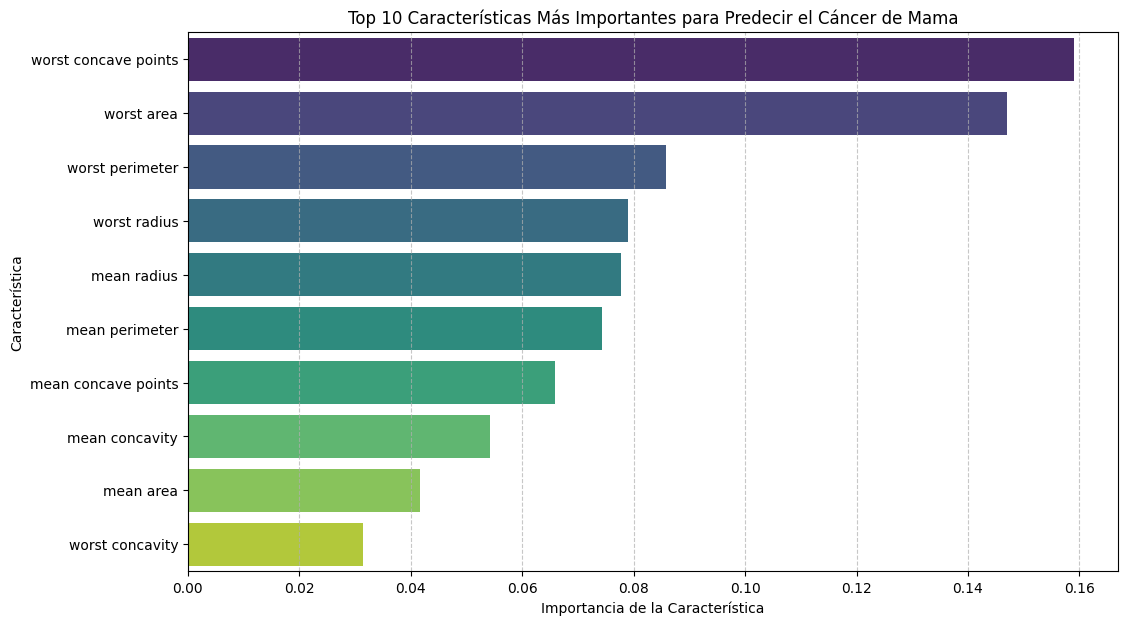

In [4]:
# Entrenar un modelo RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Obtener la importancia de las características
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Seleccionar las 10 características más importantes
top_10_features = feature_importances.nlargest(10)

# Visualizar la importancia de las características
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 Características Más Importantes para Predecir el Cáncer de Mama')
plt.xlabel('Importancia de la Característica')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Las variables más importantes para predecir la columna `target` (tipo de tumor) son las que se muestran en el gráfico de barras. La `worst perimeter`, `worst concave points` y `worst radius` parecen ser las más influyentes.

### 2) Realizar Clustering de Pacientes con K-Means

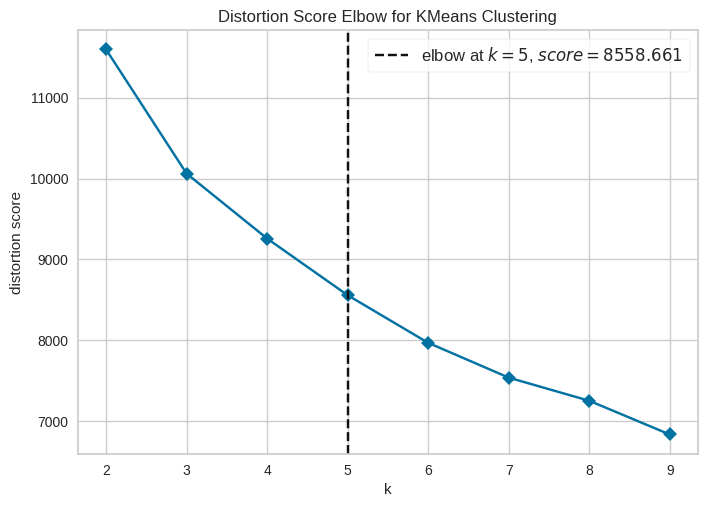

El número óptimo de clusters sugerido por el método del codo es: 5


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Estandarizar los datos para el clustering (excluyendo la columna 'target')
X_scaled = StandardScaler().fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Determinar el número óptimo de clusters usando el método del codo
model_kmeans = KMeans(random_state=42, n_init=10) # n_init is set to 'auto' or explicitly to avoid warning in newer versions
visualizer = KElbowVisualizer(model_kmeans, k=(2,10), timings=False)

visualizer.fit(X_scaled) # Fit the data to the visualizer
visualizer.show() # Finalize and render the figure

print(f"El número óptimo de clusters sugerido por el método del codo es: {visualizer.elbow_value_}")

In [6]:
# Aplicar K-Means con el número óptimo de clusters
optimal_clusters = visualizer.elbow_value_
if optimal_clusters is None: # Fallback if elbow_value_ is not found by visualizer
    optimal_clusters = 3 # Default to 3 if elbow method fails to find a clear elbow

kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Añadir los clusters al DataFrame original
df_clustered = df.copy()
df_clustered['cluster'] = clusters

print(f"Número de clusters identificados: {optimal_clusters}")
print("Conteo de pacientes por cluster:\n", df_clustered['cluster'].value_counts())

Número de clusters identificados: 5
Conteo de pacientes por cluster:
 cluster
0    204
1    161
2     99
4     70
3     35
Name: count, dtype: int64


#### Análisis de las características celulares que diferencian a los clusters

Medias de las características por cluster:
          mean radius  mean texture  mean perimeter    mean area  \
cluster                                                           
0          13.017431     18.627304       83.335882   531.118627   
1          11.503578     17.644534       74.210124   413.118012   
2          18.476667     21.414444      121.144343  1073.545455   
3          21.378000     22.403143      144.185714  1442.937143   
4          13.619671     20.441857       90.603429   585.541429   

         mean smoothness  mean compactness  mean concavity  \
cluster                                                      
0               0.084840          0.063102        0.032841   
1               0.101267          0.092960        0.052776   
2               0.098478          0.122442        0.141926   
3               0.109356          0.211546        0.265866   
4               0.109155          0.171499        0.171062   

         mean concave points  mean symmetry  mean f

/tmp/ipykernel_840/1505754029.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_clustered, ax=axes[i], palette='viridis')
/tmp/ipykernel_840/1505754029.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_clustered, ax=axes[i], palette='viridis')
/tmp/ipykernel_840/1505754029.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_clustered, ax=axes[i], palette='viridis')
/tmp/ipykernel_840/1505754029.py:17: FutureWarning: 

Passing `palette` with

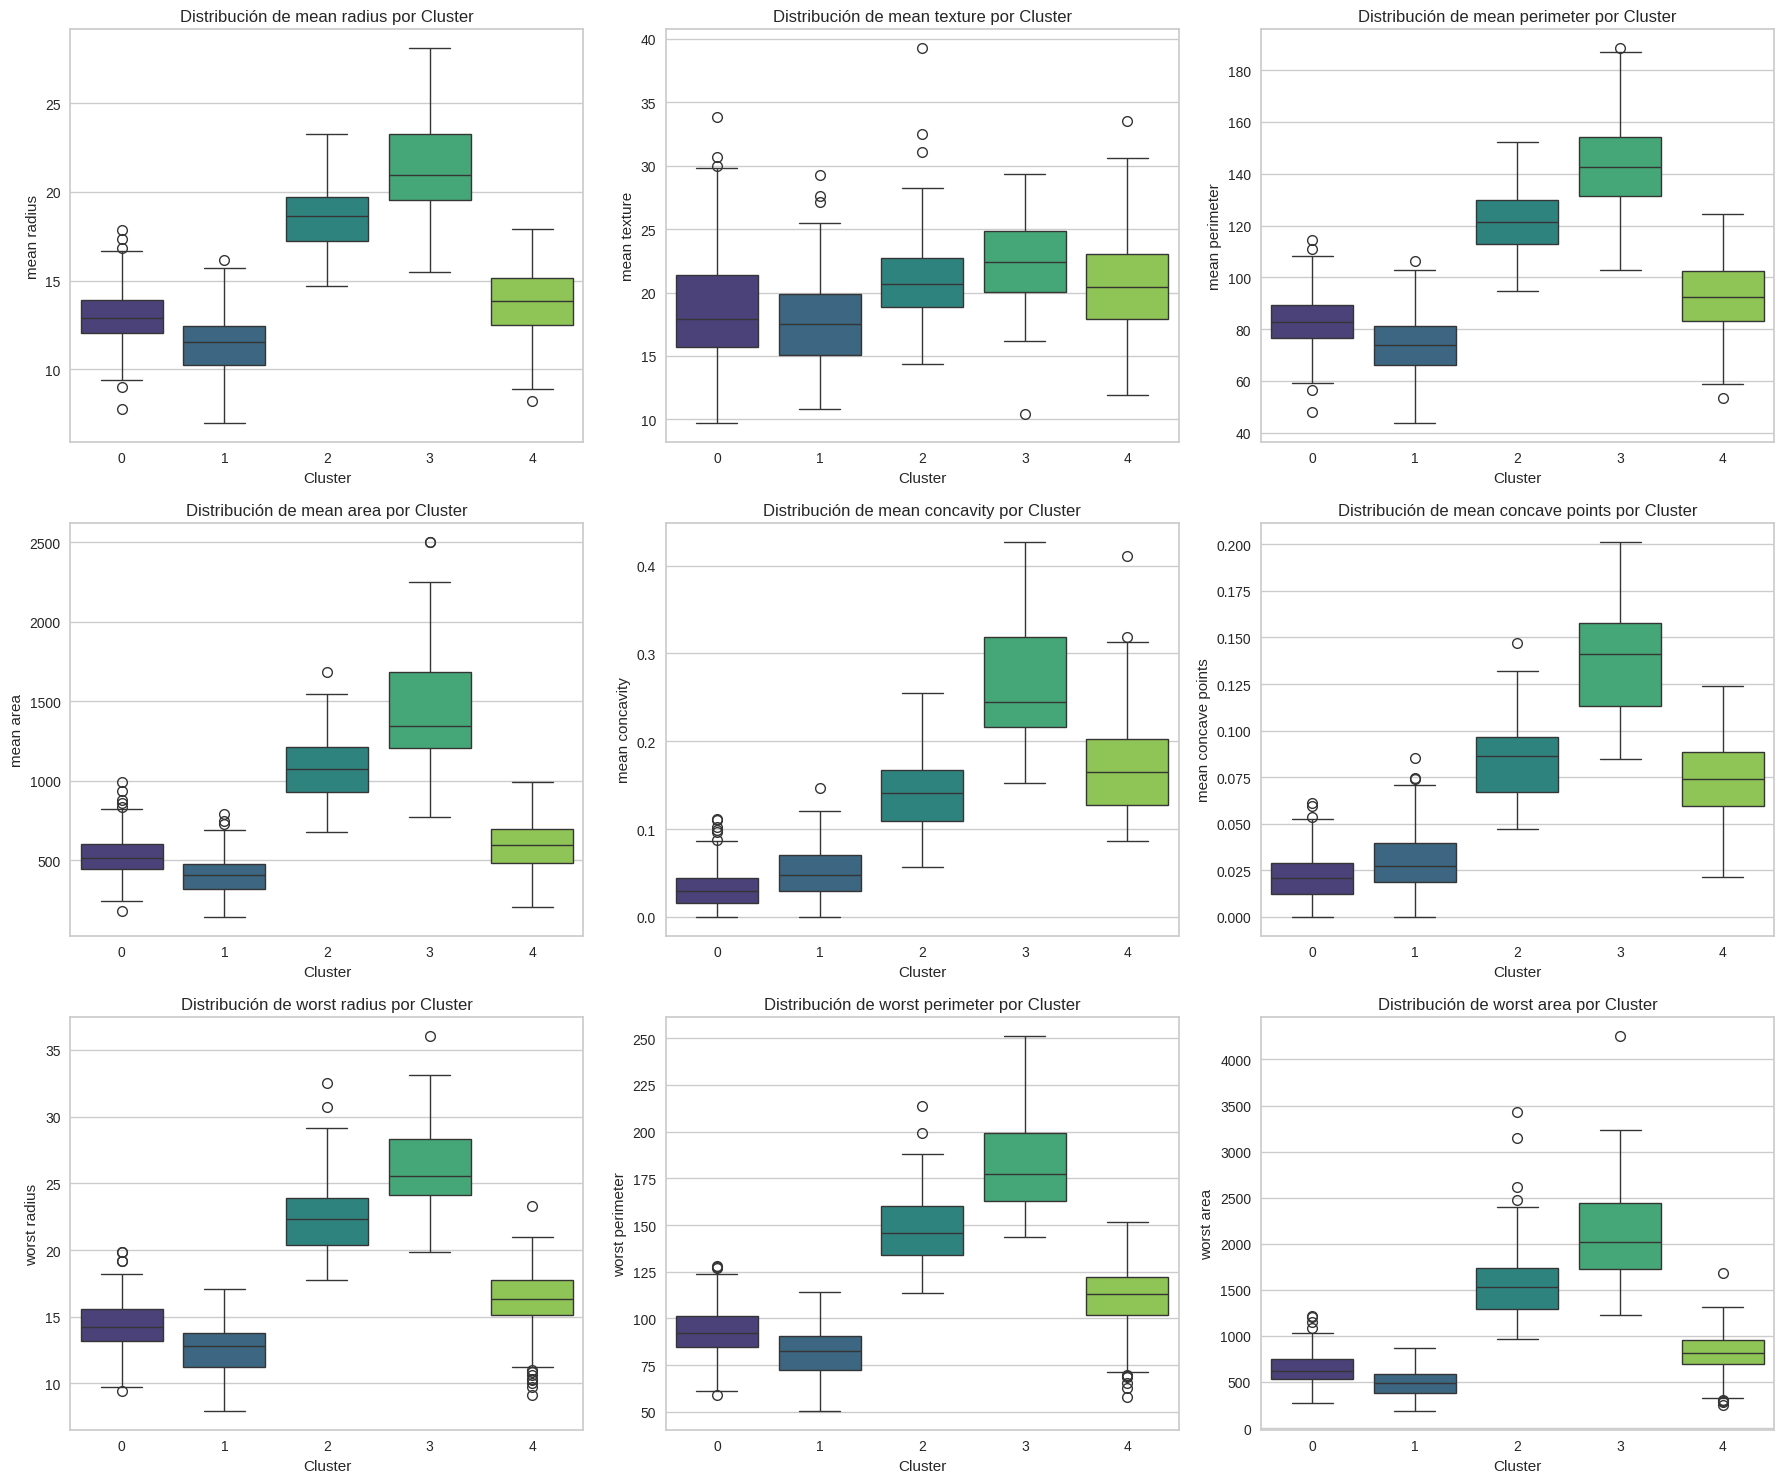

In [7]:
# Calcular las medias de las características por cluster
cluster_means = df_clustered.groupby('cluster').mean()

print("Medias de las características por cluster:\n", cluster_means)

# Visualizar algunas características clave por cluster
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Seleccionar algunas características representativas para visualizar
# Puedes ajustar esta lista según las características más importantes o las que tengan mayor varianza entre clusters
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                     'mean concavity', 'mean concave points', 'worst radius',
                     'worst perimeter', 'worst area']

for i, feature in enumerate(selected_features):
    sns.boxplot(x='cluster', y=feature, data=df_clustered, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {feature} por Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

#### Uso del resultado del clustering para priorizar pacientes o diseñar estrategias de seguimiento

Basándonos en las características que diferencian a los clusters, podríamos diseñar estrategias personalizadas:

*   **Priorización de pacientes:** Los clusters con valores más altos en características asociadas a la malignidad (como `worst concave points`, `worst area`, `worst perimeter`, `mean radius`, `mean concavity`, etc.) podrían ser considerados de mayor riesgo y, por lo tanto, priorizados para un seguimiento más intensivo o pruebas adicionales.

*   **Estrategias de seguimiento:**
    *   Para pacientes en clusters de 'bajo riesgo' (características más cercanas a tumores benignos), se podría recomendar un seguimiento rutinario menos frecuente.
    *   Para pacientes en clusters de 'alto riesgo' (características más cercanas a tumores malignos), se podría implementar un protocolo de seguimiento más estricto, incluyendo visitas más frecuentes, mamografías o biopsias.
    *   Para clusters intermedios, se podrían definir estrategias de seguimiento personalizadas basadas en el perfil específico de características que los definen.

El clustering ayuda a identificar grupos homogéneos de pacientes, lo que permite una medicina más personalizada y eficiente en la gestión de casos de cáncer de mama.